=== Phase 1: Data Ingestion ===
Please upload the patient telemetry CSV files.


Saving 1.csv to 1.csv
Saving 2.csv to 2.csv
Saving 3.csv to 3.csv
Saving 4.csv to 4.csv
Saving 5.csv to 5.csv
Saving 6.csv to 6.csv
Saving 7.csv to 7.csv
Saving 8.csv to 8.csv
Saving 9.csv to 9.csv
Saving 10.csv to 10.csv
Saving 11.csv to 11.csv
Saving 12.csv to 12.csv
Saving 13.csv to 13.csv
Saving 14.csv to 14.csv
Saving 15.csv to 15.csv
Saving 16.csv to 16.csv
Saving 17.csv to 17.csv
Saving 18.csv to 18.csv
Saving 19.csv to 19.csv
Saving 20.csv to 20.csv
Saving 21.csv to 21.csv
Saving 22.csv to 22.csv
Saving 23.csv to 23.csv
Saving 24.csv to 24.csv
Saving 25.csv to 25.csv
Saving 26.csv to 26.csv
Saving 27.csv to 27.csv
Saving 28.csv to 28.csv
Saving 29.csv to 29.csv
Saving 30.csv to 30.csv
Saving 31.csv to 31.csv
Saving 32.csv to 32.csv
Saving 33.csv to 33.csv
Saving 34.csv to 34.csv
Saving 35.csv to 35.csv
Saving 36.csv to 36.csv
Saving 37.csv to 37.csv
Saving 38.csv to 38.csv
Saving 39.csv to 39.csv
Saving 40.csv to 40.csv
Saving 41.csv to 41.csv
Saving 42.csv to 42.csv
Saving 43.

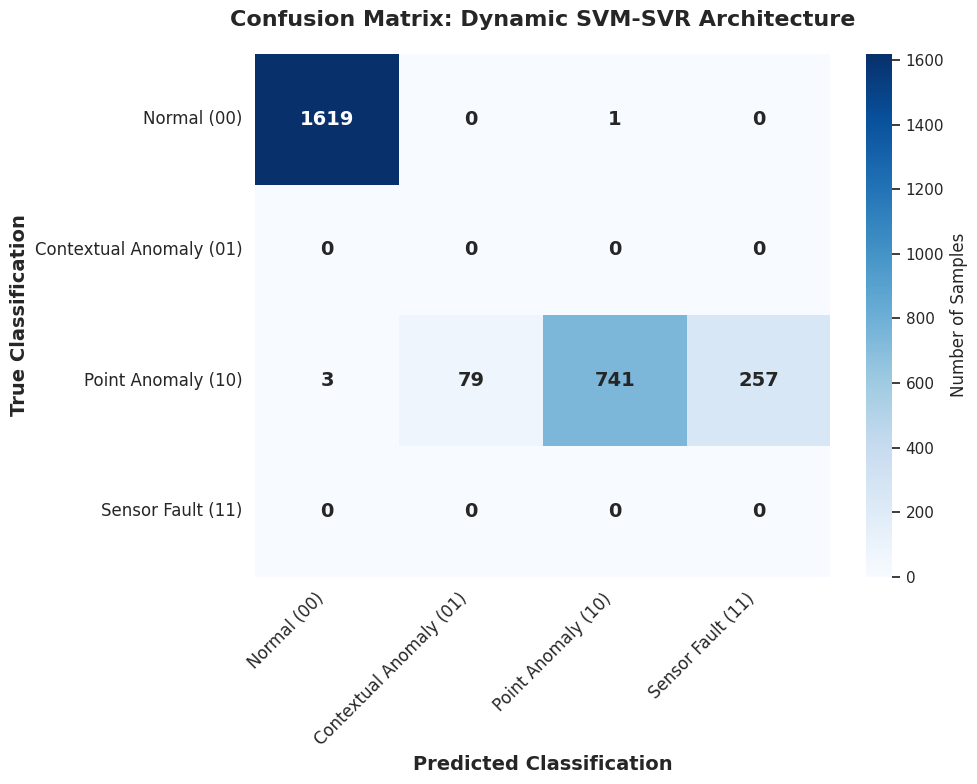

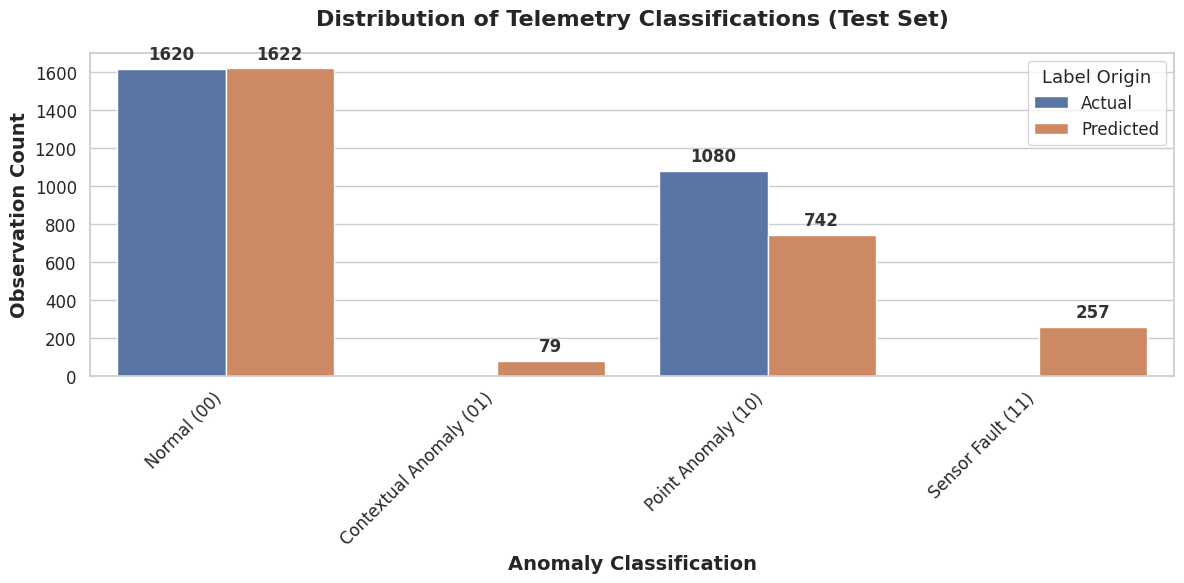

[Export] Visualizations saved as 'Fig1_Confusion_Matrix.png' and 'Fig2_Class_Distribution.png'
=== Execution Complete ===


In [ ]:
import pandas as pd
import numpy as np
import io
import sys
import re
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import RandomOverSampler

# Configure Seaborn for professional, publication-quality plots
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# PHASE 1: DATA INGESTION & AGGREGATION
# ==========================================
print("=== Phase 1: Data Ingestion ===")
print("Please upload the patient telemetry CSV files.")
uploaded = files.upload()

if not uploaded:
    print("[Error] No files uploaded. Terminating execution.")
    sys.exit()

# Helper function for chronological sorting of telemetry files
def numerical_sort(value):
    parts = re.split(r'(\d+)', value)
    parts[1::2] = map(int, parts[1::2])
    return parts

sorted_filenames = sorted(uploaded.keys(), key=numerical_sort)

df_list = []
for filename in sorted_filenames:
    temp_df = pd.read_csv(io.BytesIO(uploaded[filename]))
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

try:
    # Ground truth encoding
    df['Actual_Code'] = df.iloc[:, 5].astype(str) + df.iloc[:, 6].astype(str)
except IndexError:
    print("[Error] Required Anomaly_Type and Normal columns missing at indices 5/6.")
    sys.exit()

print(f"[Info] Aggregated Dataset Loaded: {len(df)} total observations from {len(df_list)} files.\n")

# ==========================================
# PHASE 2: TEMPORAL FEATURE ENGINEERING
# ==========================================
print("=== Phase 2: Temporal Feature Extraction ===")
features = ['Body_Temperature', 'Heart_Rate', 'Pulse_Rate', 'SpO2', 'ECG']

# Generating moving statistics for dynamic baseline monitoring
for col in features:
    df[f'{col}_roll_mean'] = df[col].rolling(window=5).mean()
    df[f'{col}_roll_std'] = df[col].rolling(window=5).std()

df = df.bfill().ffill()

X = df.drop(columns=['Anomaly_Type', 'Normal', 'Actual_Code'])
y = df['Actual_Code'].astype(str)

# Stratified split to preserve class distribution in test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("[Info] Feature engineering complete. Dataset split into Train (80%) and Test (20%).\n")

# ==========================================
# PHASE 3: DATA NORMALIZATION
# ==========================================
print("=== Phase 3: Data Normalization ===")
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

y_train_str = y_train.values
y_test_reset = y_test.reset_index(drop=True)
y_test_str = y_test_reset.values
X_test_original = X_test.reset_index(drop=True)
print("[Info] MinMaxScaler applied to feature set.\n")

# ==========================================
# PHASE 4: HYBRID MODEL TRAINING (SVM + SVR)
# ==========================================
print("=== Phase 4: Model Training & Boundary Optimization ===")

# Binary mapping for Stage 1 SVM (Normal vs. Abnormal)
y_train_binary = (y_train_str != '00').astype(int)

# Handle class imbalance for robust hyper-plane generation
ros = RandomOverSampler(random_state=42)
X_train_svm_resampled, y_train_binary_resampled = ros.fit_resample(X_train_scaled, y_train_binary)

# Train Stage 1 SVM
svm = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
svm.fit(X_train_svm_resampled, y_train_binary_resampled)

X_train_normal_scaled = X_train_scaled[y_train_str == '00']
X_train_normal_orig = X_train[y_train_str == '00']

dynamic_global_bounds = {}
dynamic_min_jumps = {}
dynamic_fault_thresholds = {}

# Compute Dynamic Statistical Boundaries
for feat in features:
    sensor_scale = X_train[feat].std()
    normal_min = X_train_normal_orig[feat].min()
    normal_max = X_train_normal_orig[feat].max()

    dynamic_global_bounds[feat] = (normal_min - (sensor_scale * 1.0), normal_max + (sensor_scale * 1.0))
    dynamic_min_jumps[feat] = sensor_scale * 0.30
    dynamic_fault_thresholds[feat] = max(normal_min - (sensor_scale * 2.5), 5.0)

svr_models = {}
baseline_residuals = {}

# Train Stage 2 SVRs for contextual prediction
for feature in features:
    X_svr = X_train_normal_scaled.drop(columns=[feature])
    y_svr = X_train_normal_scaled[feature]

    svr = SVR(kernel='rbf', C=1.0)
    svr.fit(X_svr, y_svr)
    svr_models[feature] = svr

    preds = svr.predict(X_svr)
    baseline_residuals[feature] = np.percentile(np.abs(y_svr - preds), 95)

print("[Info] Hybrid SVM-SVR pipeline successfully trained.\n")

# ==========================================
# PHASE 5: DYNAMIC INFERENCE ON TEST SET
# ==========================================
print(f"=== Phase 5: Dynamic Inference ===")
print(f"[Info] Evaluating {len(X_test_scaled)} unseen test samples...")
output_rows = []

svm_predictions = svm.predict(X_test_scaled)

for i in range(len(X_test_scaled)):
    row_scaled = X_test_scaled.iloc[i]
    row_orig = X_test_original.iloc[i]
    actual_code = y_test_str[i]

    pred_code = "00"

    if svm_predictions[i] == 1:
        # Check A: Hardware/Sensor Fault
        if row_orig['Heart_Rate'] < dynamic_fault_thresholds['Heart_Rate'] or \
           row_orig['SpO2'] < dynamic_fault_thresholds['SpO2']:
            pred_code = "11"
        else:
            # Check B: Point Anomaly
            is_point_anomaly = False
            for feat in ['Heart_Rate', 'SpO2', 'Body_Temperature']:
                actual_val = row_orig[feat]
                mean_val = row_orig[f'{feat}_roll_mean']
                std_val = row_orig[f'{feat}_roll_std']

                if actual_val < dynamic_global_bounds[feat][0] or actual_val > dynamic_global_bounds[feat][1]:
                    is_point_anomaly = True
                    break

                if not pd.isna(std_val):
                    allowed_variance = max((3 * std_val), dynamic_min_jumps[feat])
                    if actual_val > (mean_val + allowed_variance) or actual_val < (mean_val - allowed_variance):
                        is_point_anomaly = True
                        break

            if is_point_anomaly:
                pred_code = "10"
            else:
                # Check C: Contextual Anomaly
                context_votes = 0
                for feat in features:
                    input_row = row_scaled.drop(labels=[feat]).to_frame().T
                    pred_val = svr_models[feat].predict(input_row)[0]
                    residual = abs(row_scaled[feat] - pred_val)

                    if residual > baseline_residuals[feat]:
                        context_votes += 1

                if context_votes >= 1:
                    pred_code = "01"
                else:
                    pred_code = "10" # Fallback mapping

    output_rows.append({
        'Row_ID': X_test.index[i],
        'Actual': actual_code,
        'Predicted': pred_code,
        'Match': actual_code == pred_code
    })

results_df = pd.DataFrame(output_rows)

# ==========================================
# PHASE 6: EVALUATION METRICS & EXPORT
# ==========================================
print("\n" + "="*80)
print("                  MODEL EVALUATION REPORT")
print("="*80)

# Dictionary to map codes to readable labels for the report
class_names = {
    '00': 'Normal (00)',
    '01': 'Contextual Anomaly (01)',
    '10': 'Point Anomaly (10)',
    '11': 'Sensor Fault (11)'
}

y_true = results_df['Actual']
y_pred = results_df['Predicted']

existing_codes = sorted(list(set(y_true) | set(y_pred)))
target_names = [class_names.get(code, code) for code in existing_codes]

print(classification_report(y_true, y_pred, labels=existing_codes, target_names=target_names, zero_division=0))

acc_score = accuracy_score(y_true, y_pred)
print("\n" + "#"*50)
print(f"      OVERALL TEST ACCURACY: {acc_score * 100:.2f}%")
print("#"*50 + "\n")

# Save Predictions
csv_filename = 'WBAN_Model_Evaluation_Results.csv'
results_df.to_csv(csv_filename, index=False)
print(f"[Export] Detailed predictions saved to '{csv_filename}'")

# ==========================================
# PHASE 7: FORMAL VISUALIZATIONS
# ==========================================
print("[Export] Generating publication-ready visualizations...")

# Calculate the confusion matrix 'cm' before plotting ---
cm = confusion_matrix(y_true, y_pred, labels=existing_codes)

# 1. Confusion Matrix Heatmap
plt.figure(figsize=(10, 8)) # Slightly larger to accommodate long labels
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=target_names, yticklabels=target_names,
                 cbar_kws={'label': 'Number of Samples'},
                 annot_kws={"size": 14, "weight": "bold"}) # Bigger, bolder numbers inside the matrix

plt.title('Confusion Matrix: Dynamic SVM-SVR Architecture', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Classification', fontsize=14, fontweight='bold')

# Rotate x-labels 45 degrees so they don't overlap, keep y-labels perfectly horizontal
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# bbox_inches='tight' guarantees rotated labels don't get cut off
plt.tight_layout()
plt.savefig('Fig1_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Class Distribution Plot (Actual vs Predicted)
dist_df = pd.DataFrame({
    'Actual': [class_names.get(x, x) for x in y_true],
    'Predicted': [class_names.get(x, x) for x in y_pred]
})
dist_melted = dist_df.melt(var_name='Dataset', value_name='Class')

plt.figure(figsize=(12, 6)) # Made wider so categories fit beautifully
ax = sns.countplot(data=dist_melted, x='Class', hue='Dataset', palette=['#4C72B0', '#DD8452'], order=target_names)

plt.title('Distribution of Telemetry Classifications (Test Set)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Observation Count', fontsize=14, fontweight='bold')
plt.xlabel('Anomaly Classification', fontsize=14, fontweight='bold')

# Rotate x-labels to prevent text overlapping
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# --- THE UPGRADE: Add exact numerical counts directly on top of each bar ---
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0: # Only label bars that actually exist
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold', color='#333333',
                    xytext=(0, 4), textcoords='offset points')

plt.legend(title='Label Origin', title_fontsize='13', fontsize='12', loc='upper right')

plt.tight_layout()
plt.savefig('Fig2_Class_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("[Export] Visualizations saved as 'Fig1_Confusion_Matrix.png' and 'Fig2_Class_Distribution.png'")
print("=== Execution Complete ===")